# Circumferential average
In this notebook we present a circumferential average routine of raw CFD data. The data are extracted as csv files from Ansys, while the structured mesh of the block is calculated thanks to user defined functions and blade curves.
Let's start with importing the needed things:

In [1]:
import matplotlib.pyplot as plt
import sys
sys.path.append('../../')
import Grid

Instantiate the block for the blade, and compute the important things needed for the meridional data processing

In [2]:
data_folder_path = '../../Grid/geo/'
units = '[m]'
nstream = 45
nspan = 20
hub = Grid.src.Curve(curve_filepath=data_folder_path + 'iris_hub.curve', units='m', degree_spline=3)
shroud = Grid.src.Curve(curve_filepath=data_folder_path + 'iris_shroud.curve', units='m', degree_spline=3)
bladed_block = Grid.src.Block(hub, shroud, blade_file=data_folder_path + 'iris_blade.curve', block_type='blade',
                     nstream=nstream, nspan=nspan)
# instantiate blade object
blade = Grid.src.Blade(data_folder_path + 'iris_blade.curve')
blade.find_camber_surface()
blade.find_inlet_points()
blade.find_outlet_points()
bladed_block.add_inlet_outlet_curves(blade.inlet, blade.outlet)
bladed_block.extend_inlet_outlet_curves()
bladed_block.find_intersections()
bladed_block.bladed_zone_trim()
bladed_block.spline_of_trim()
bladed_block.sample(sampling_mode='clustering')
bladed_block.compute_span_points(sampling_mode='clustering')
bladed_block.compute_double_grid()

read the data from CFD

In [4]:
filename = '../../Grid/data/iris_85krpm_0.11kgs.csv'
data = Grid.src.CfdData(filename, rpm_shaft=-85e3)

instantiate object for the meridional data processing, and perform circumferential average

In [8]:
data_process = Grid.src.MeridionalProcess(bladed_block, data, blade)
data_process.circumferential_average()

and do the same, but using gaussing filtering

In [10]:
data_process_filt = Grid.src.MeridionalProcess(bladed_block, data, blade)
data_process_filt.circumferential_average(mode='gauss filtered')

compare the results for the raw and filtered version

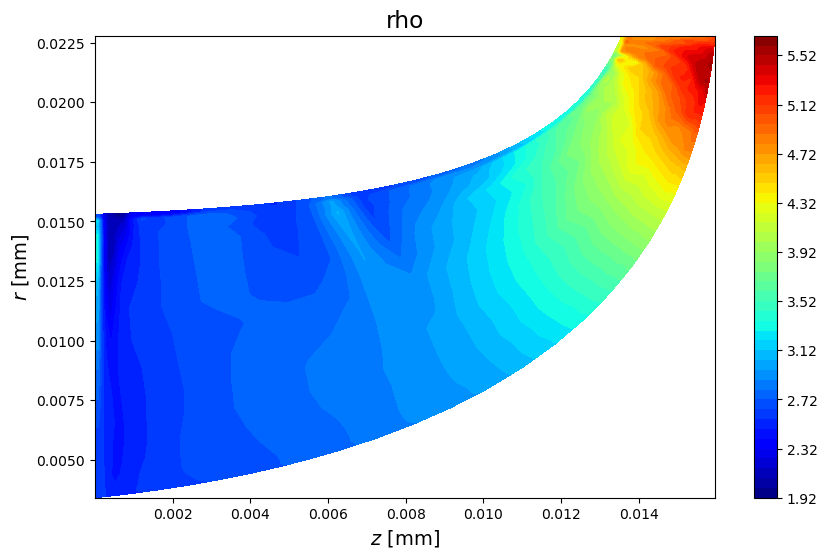

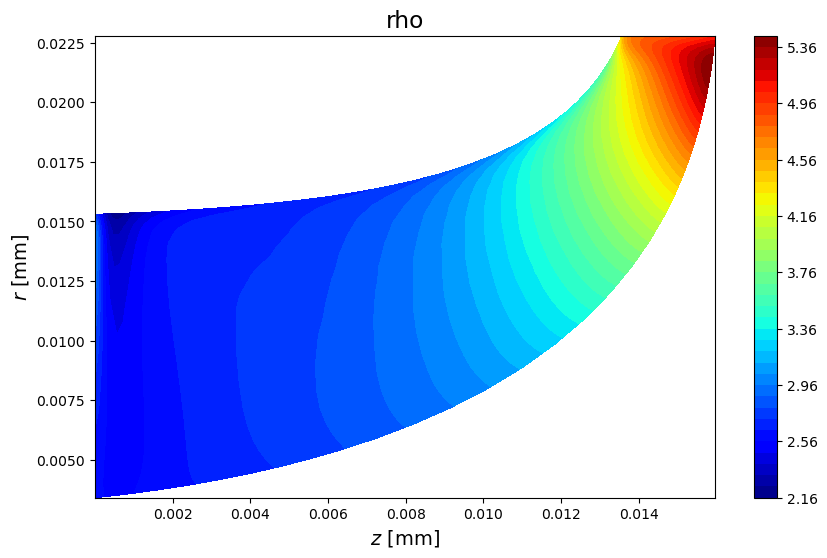

In [12]:
data_process.contour_plot('rho')
data_process_filt.contour_plot('rho')


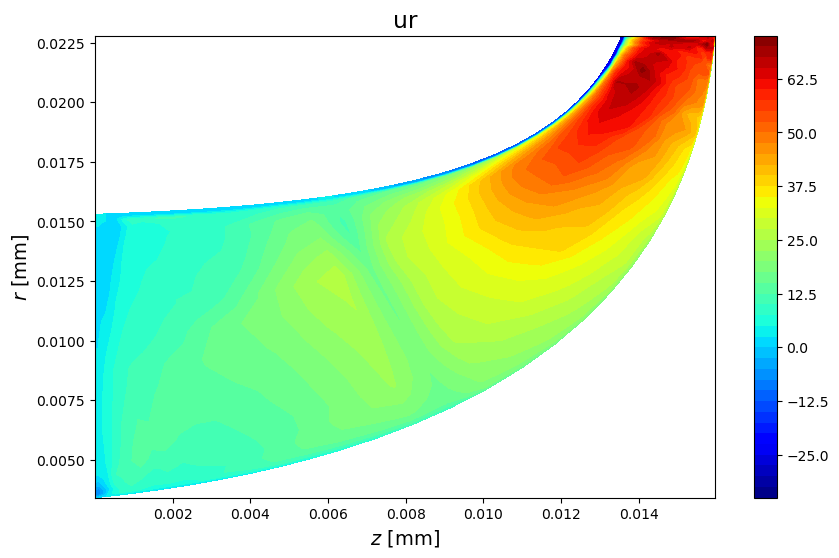

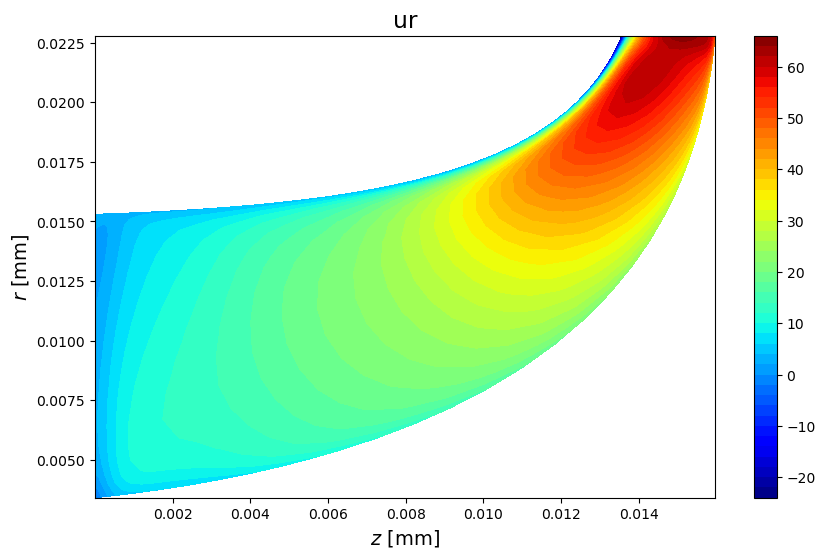

In [14]:
data_process.contour_plot('ur')
data_process_filt.contour_plot('ur')

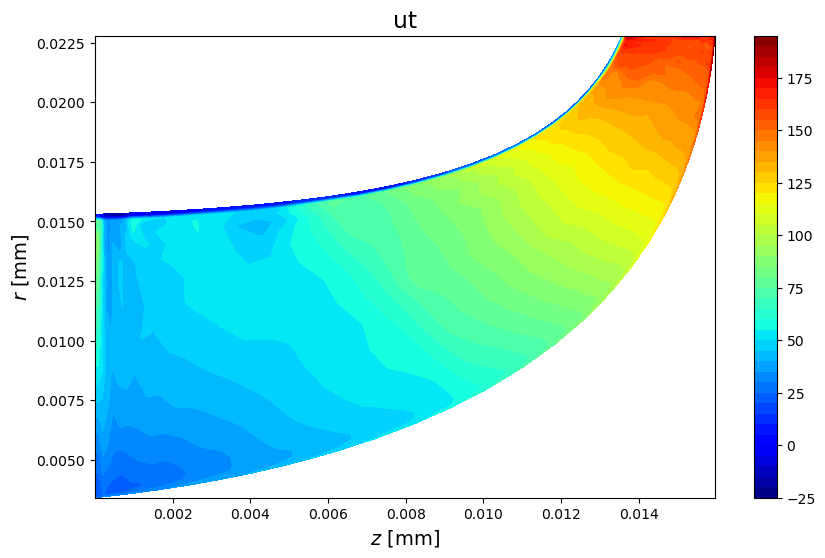

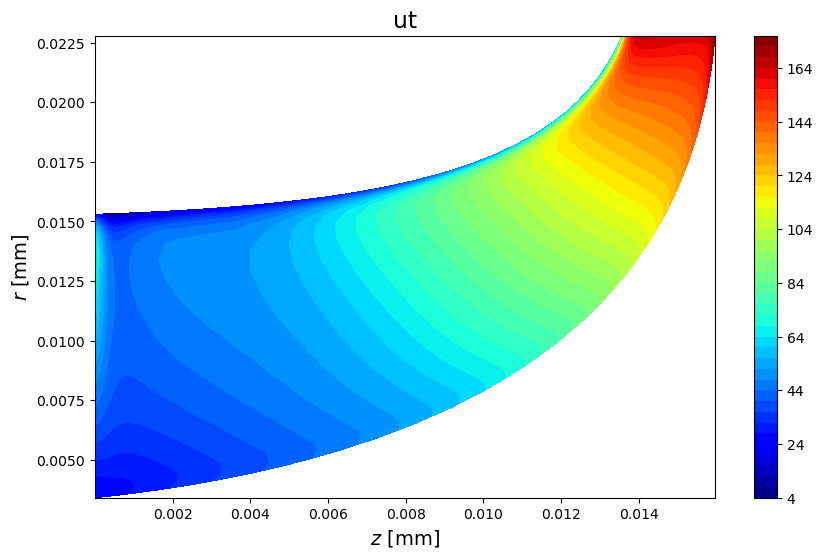

In [13]:
data_process.contour_plot('ut')
data_process_filt.contour_plot('ut')

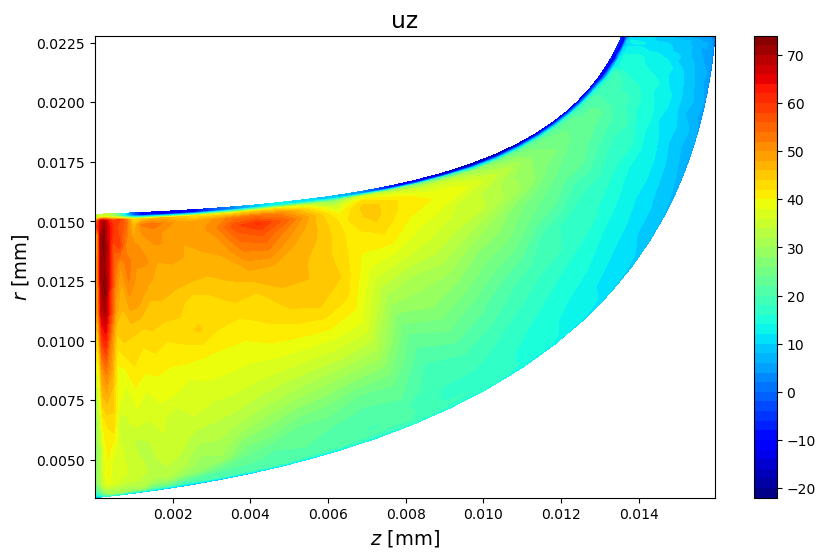

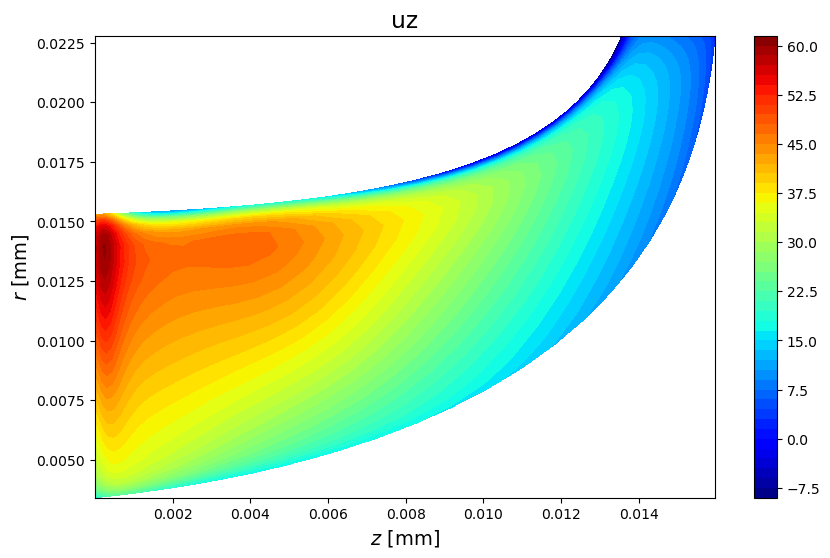

In [15]:
data_process.contour_plot('uz')
data_process_filt.contour_plot('uz')

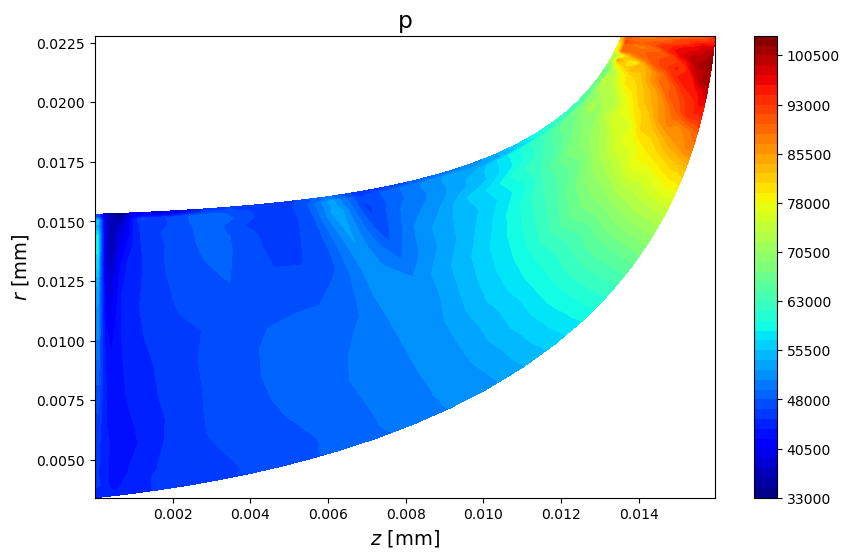

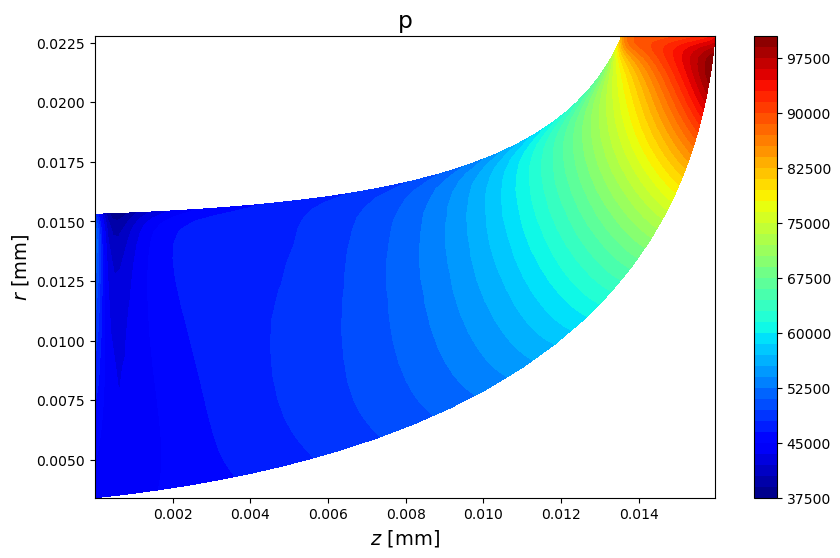

In [16]:
data_process.contour_plot('p')
data_process_filt.contour_plot('p')

# $\rho$ derivatives

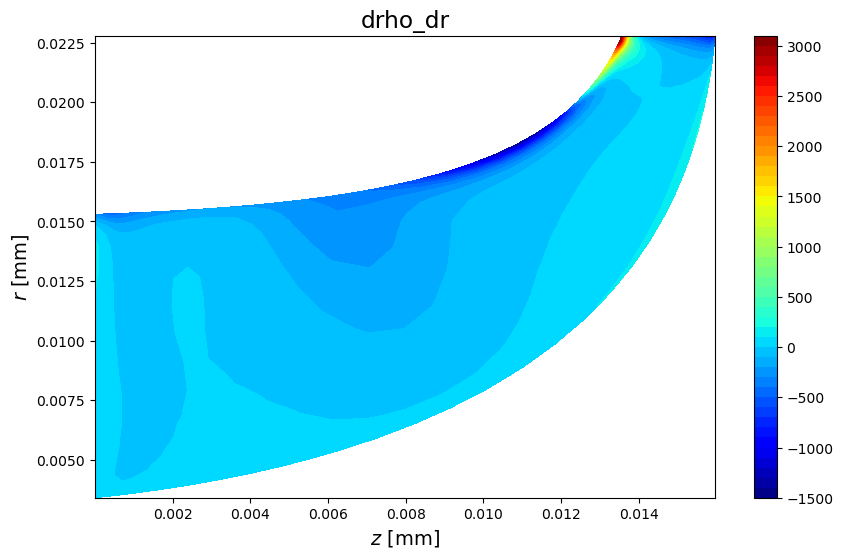

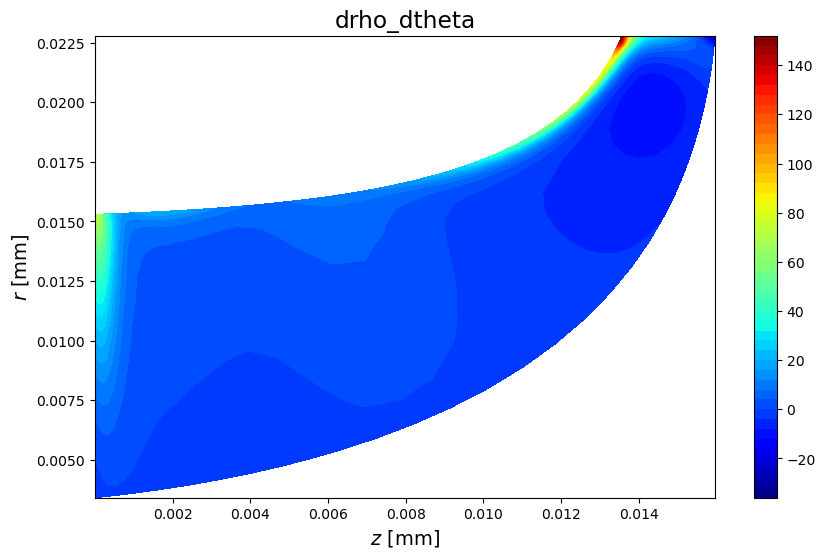

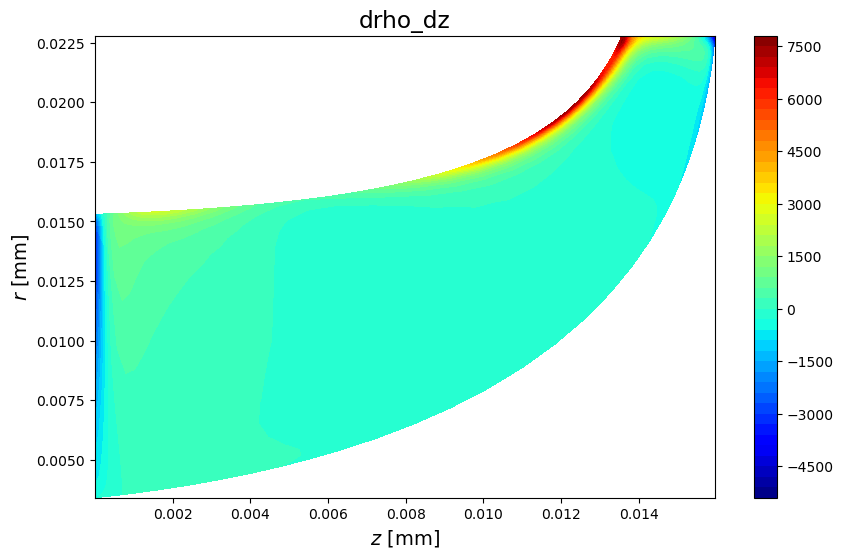

In [17]:
data_process_filt.contour_plot('drho_dr')
data_process_filt.contour_plot('drho_dtheta')
data_process_filt.contour_plot('drho_dz')

# $u_r$ derivatives

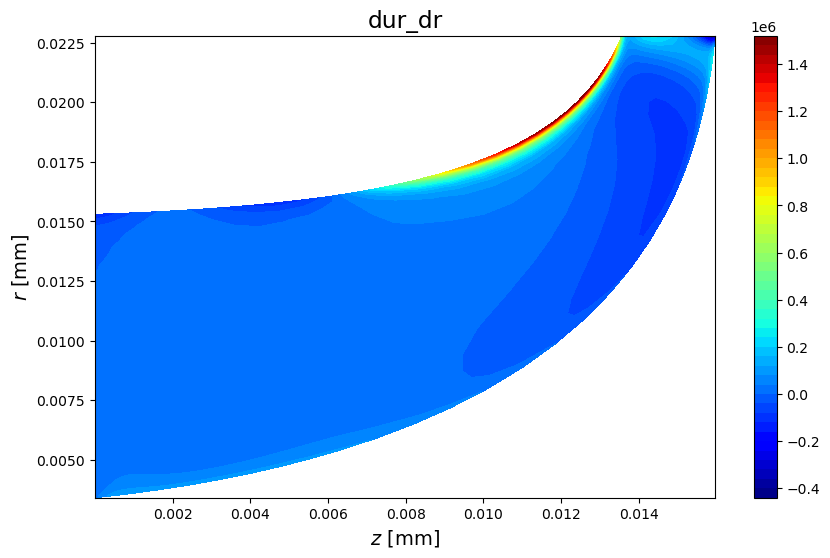

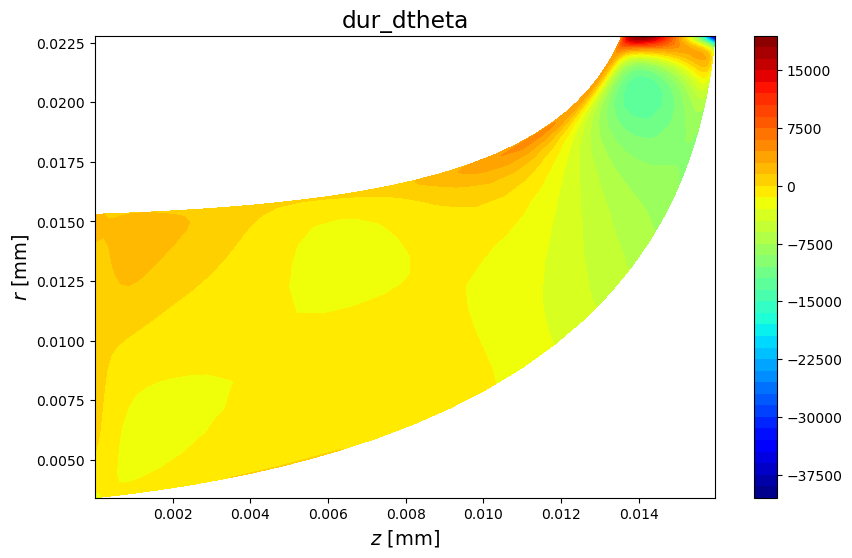

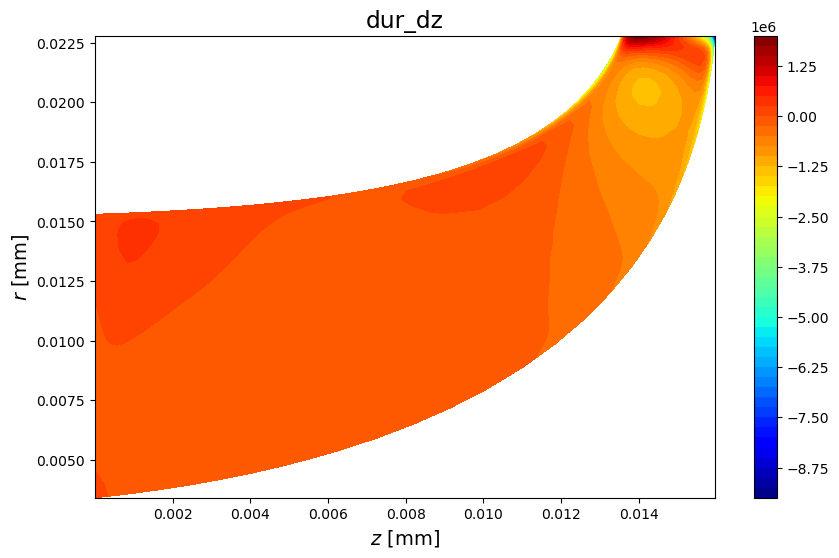

In [18]:
data_process_filt.contour_plot('dur_dr')
data_process_filt.contour_plot('dur_dtheta')
data_process_filt.contour_plot('dur_dz')

# $u_{\theta}$ derivatives

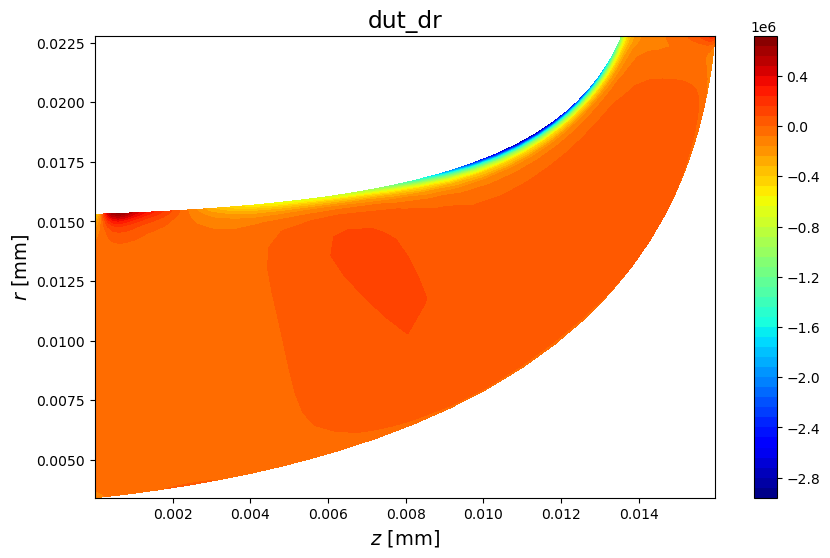

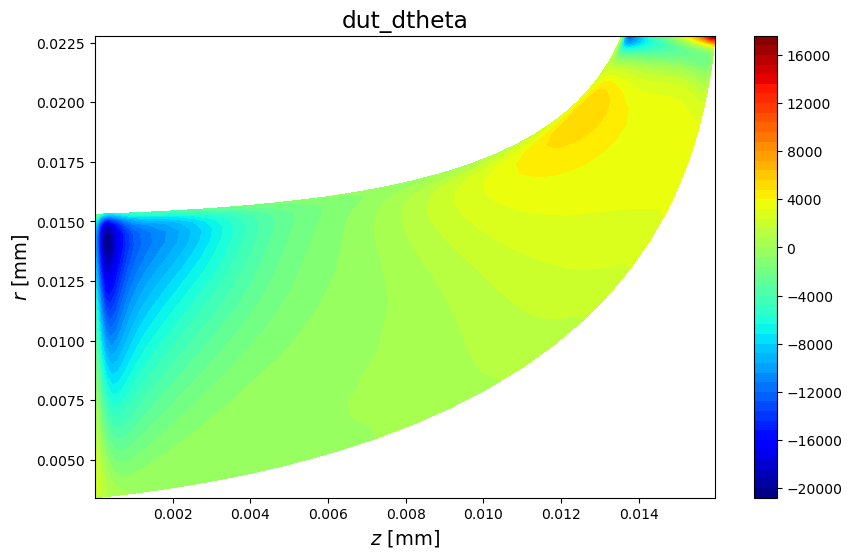

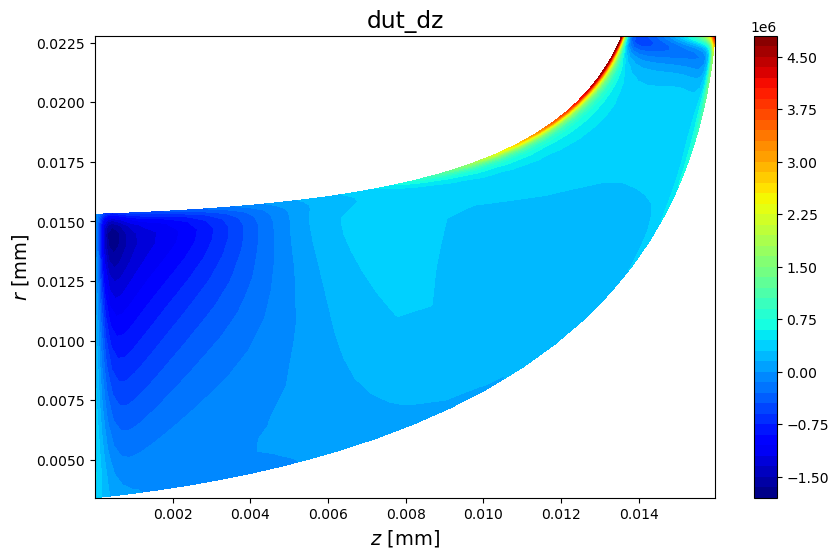

In [19]:
data_process_filt.contour_plot('dut_dr')
data_process_filt.contour_plot('dut_dtheta')
data_process_filt.contour_plot('dut_dz')

# $u_{z}$ derivatives

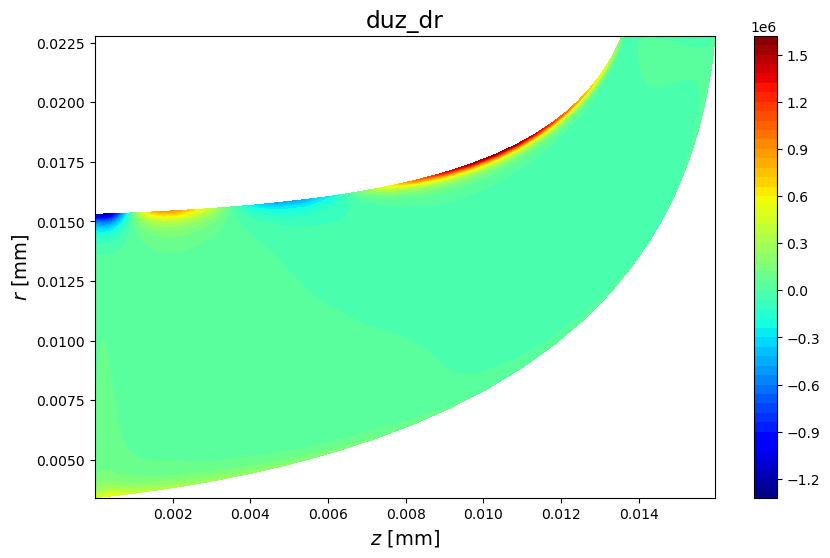

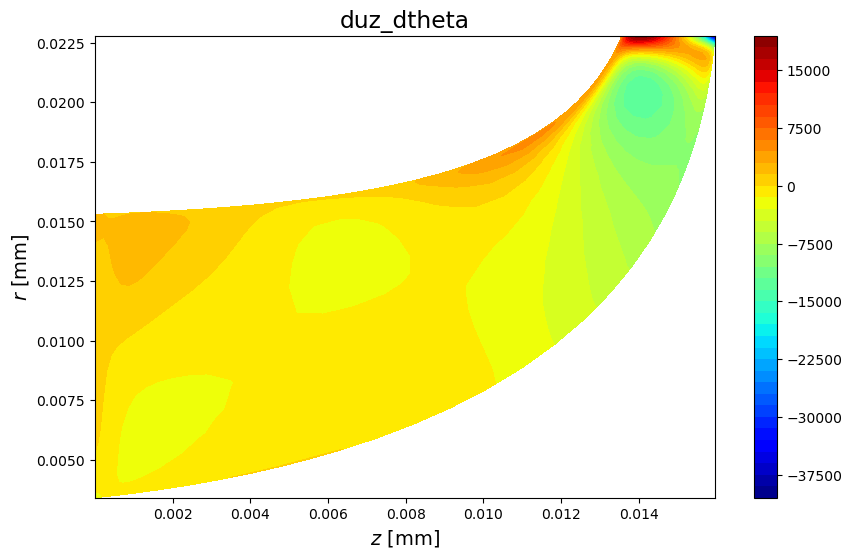

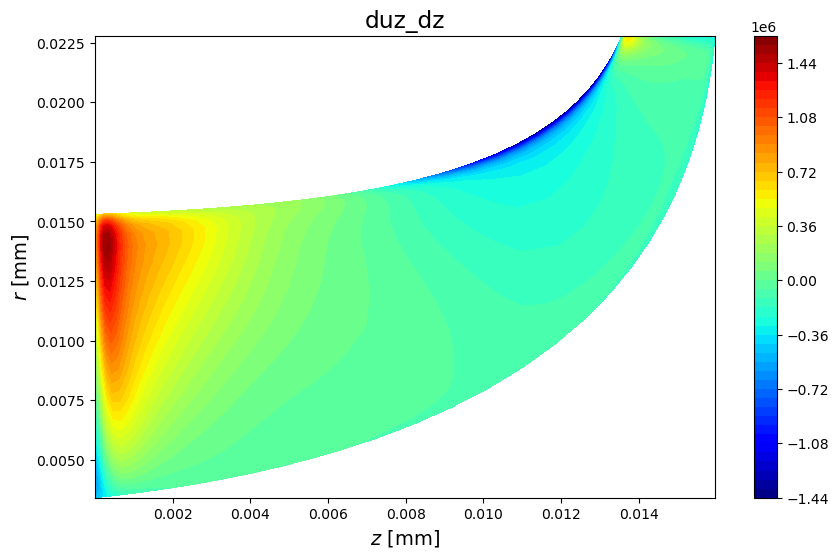

In [20]:
data_process_filt.contour_plot('duz_dr')
data_process_filt.contour_plot('duz_dtheta')
data_process_filt.contour_plot('duz_dz')

# $p$ derivatives

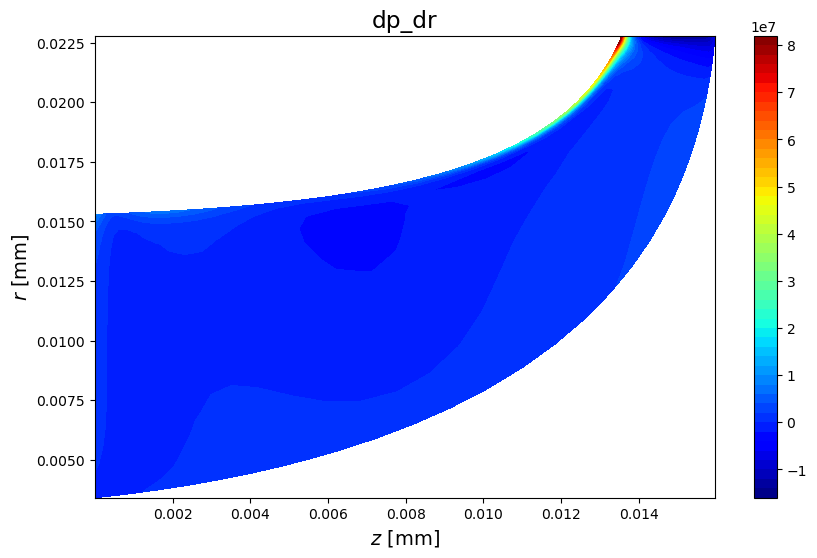

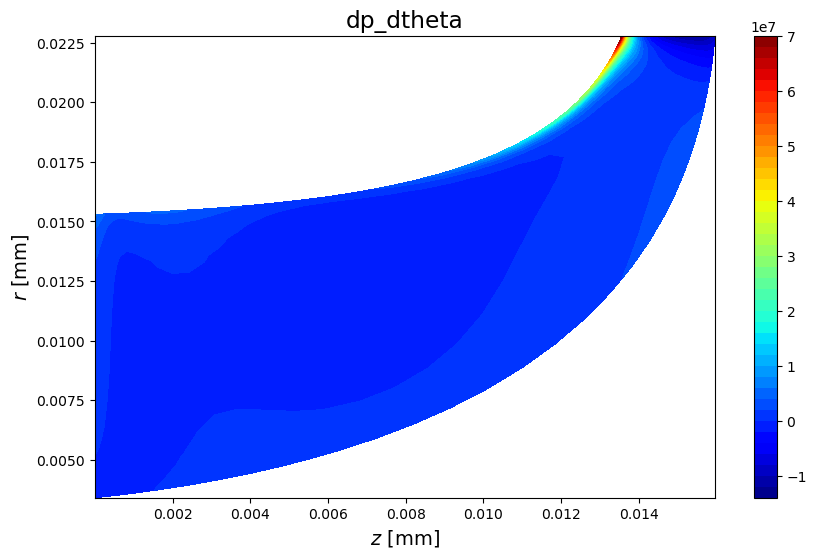

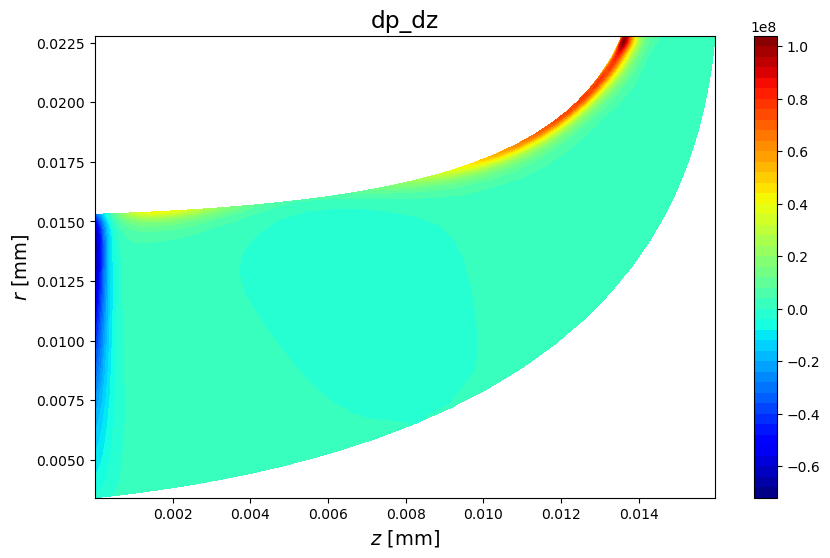

In [21]:
data_process_filt.contour_plot('dp_dr')
data_process_filt.contour_plot('dp_dtheta')
data_process_filt.contour_plot('dp_dz')

# $s$ and $\nabla s$

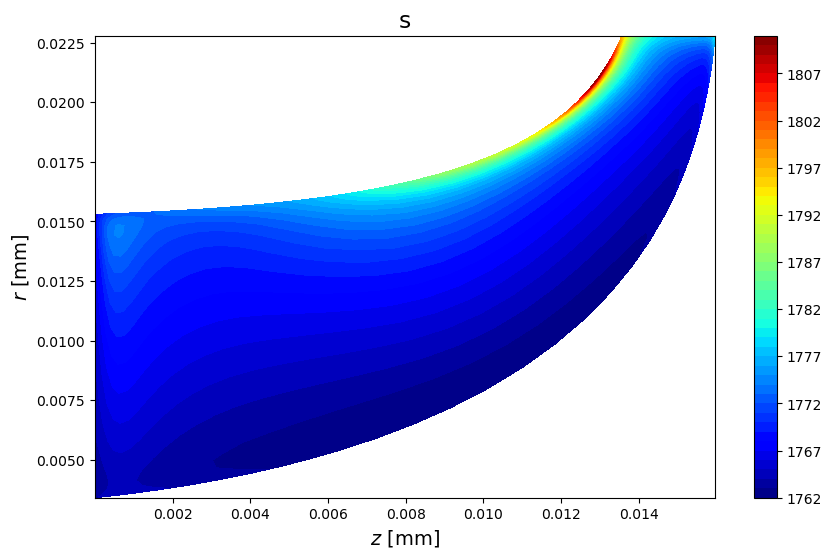

In [22]:
data_process_filt.contour_plot('s')

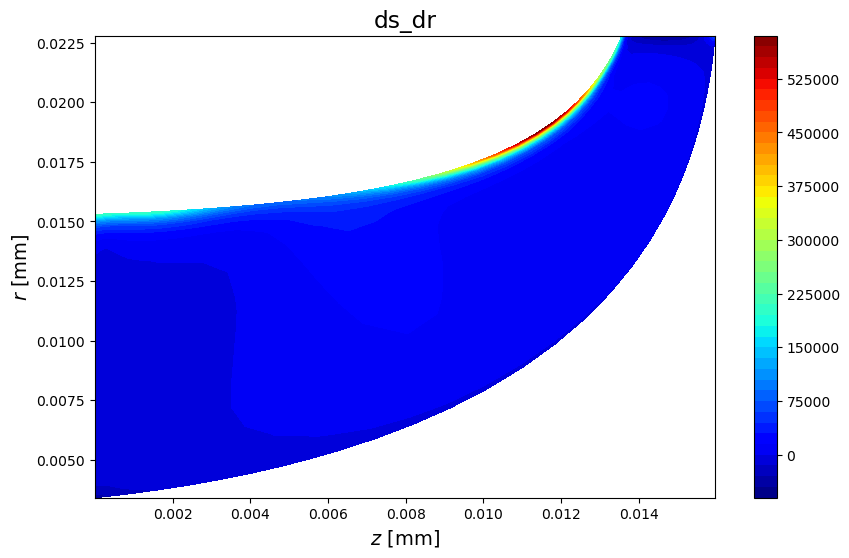

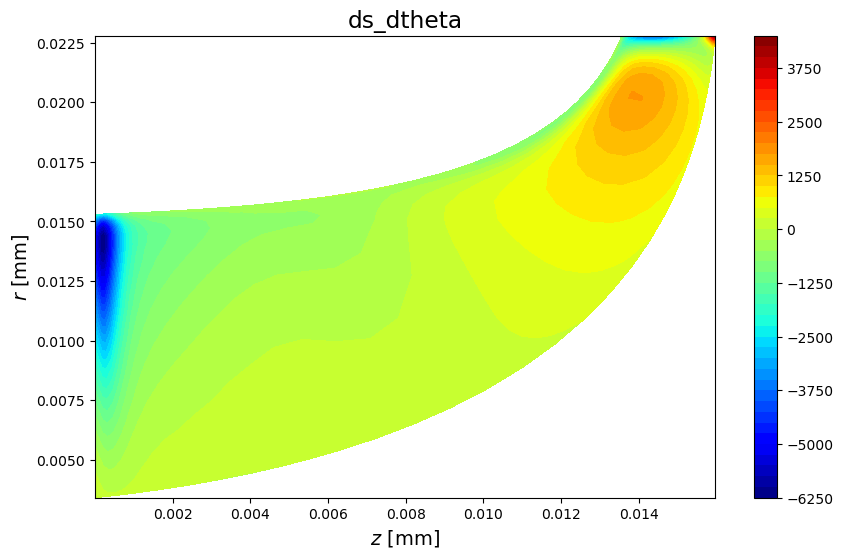

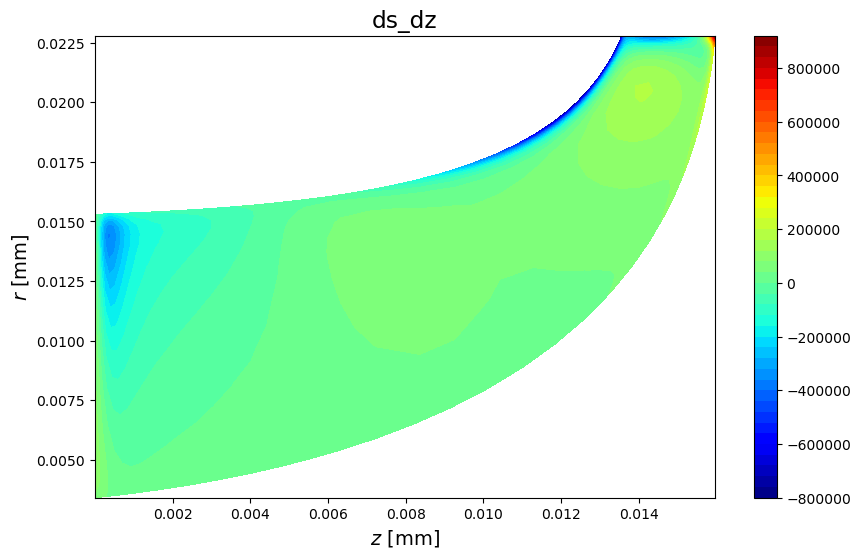

In [23]:
data_process_filt.contour_plot('ds_dr')
data_process_filt.contour_plot('ds_dtheta')
data_process_filt.contour_plot('ds_dz')